## 라이브러리 설치

In [1]:
!python -m pip install numpy pandas matplotlib folium seaborn


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## 라이브러리 임포트

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import folium

## 데이터가공 

In [3]:
bike_temp = pd.read_csv('C:/pythonexercise_self/20260522/data/bikerental-data/bike_rent_1.csv', encoding='cp949', parse_dates=['대여일시'])
bike_temp.head()

,자전거번호,대여일시,대여 대여소번호,대여 대여소명,이용시간,이용거리
0,SPB-22040,2019-06-03 08:49:00,646,장한평역 1번출구 (국민은행앞),27,1330
1,SPB-07446,2019-06-03 08:33:00,526,용답토속공원 앞,54,1180
2,SPB-20387,2019-06-05 08:27:00,646,장한평역 1번출구 (국민은행앞),12,1930
3,SPB-16794,2019-06-05 08:46:00,646,장한평역 1번출구 (국민은행앞),6,1340
4,SPB-18266,2019-06-10 08:27:00,529,장한평역 8번 출구 앞,5,1230


In [4]:
bike_dictionary={}

for file_number in range(1,7):
    bike_csv = pd.read_csv(f'C:/pythonexercise_self/20260522/data/bikerental-data/bike_rent_{file_number}.csv', encoding='cp949', parse_dates=['대여일시'])
    bike_dictionary[file_number] = bike_csv


In [5]:
bike_dictionary

{1:             자전거번호                대여일시  대여 대여소번호            대여 대여소명  이용시간  이용거리
 0       SPB-22040 2019-06-03 08:49:00       646  장한평역 1번출구 (국민은행앞)    27  1330
 1       SPB-07446 2019-06-03 08:33:00       526           용답토속공원 앞    54  1180
 2       SPB-20387 2019-06-05 08:27:00       646  장한평역 1번출구 (국민은행앞)    12  1930
 3       SPB-16794 2019-06-05 08:46:00       646  장한평역 1번출구 (국민은행앞)     6  1340
 4       SPB-18266 2019-06-10 08:27:00       529       장한평역 8번 출구 앞     5  1230
 ...           ...                 ...       ...                ...   ...   ...
 399994  SPB-16680 2019-06-28 17:14:00       316         종각역 1번출구 앞    16  2360
 399995  SPB-07874 2019-06-28 16:59:00       345         서울보증보험본사 앞    32  1880
 399996  SPB-21622 2019-06-28 16:44:00       526           용답토속공원 앞    64  6100
 399997  SPB-20056 2019-06-28 17:46:00       453  종로오가 지하쇼핑센터 14번출구     7   880
 399998  SPB-18692 2019-06-28 17:34:00       345         서울보증보험본사 앞    35  1820
 
 [399999 rows x 6 columns],
 2:    

In [6]:
print(type(bike_dictionary))

<class 'dict'>


In [8]:
print(type(bike_dictionary[1]))

<class 'pandas.DataFrame'>


In [9]:
# dataframe 합치기(concat)
# 
bikes = pd.concat(bike_dictionary, ignore_index=True)
bikes.head

<bound method NDFrame.head of              자전거번호                대여일시  대여 대여소번호            대여 대여소명  이용시간  \
0        SPB-22040 2019-06-03 08:49:00       646  장한평역 1번출구 (국민은행앞)    27   
1        SPB-07446 2019-06-03 08:33:00       526           용답토속공원 앞    54   
2        SPB-20387 2019-06-05 08:27:00       646  장한평역 1번출구 (국민은행앞)    12   
3        SPB-16794 2019-06-05 08:46:00       646  장한평역 1번출구 (국민은행앞)     6   
4        SPB-18266 2019-06-10 08:27:00       529       장한평역 8번 출구 앞     5   
...            ...                 ...       ...                ...   ...   
2215627  SPB-22438 2019-06-24 07:40:00       240         문래역 4번출구 앞    13   
2215628  SPB-24455 2019-06-25 07:34:00       240         문래역 4번출구 앞     6   
2215629  SPB-24557 2019-06-26 08:19:00       240         문래역 4번출구 앞     7   
2215630  SPB-00649 2019-06-27 07:38:00       240         문래역 4번출구 앞    11   
2215631  SPB-14209 2019-06-28 07:37:00       240         문래역 4번출구 앞     6   

         이용거리  
0        1330  
1        1180

In [19]:
bikes.iloc[399995: 400005]

,자전거번호,대여일시,대여 대여소번호,대여 대여소명,이용시간,이용거리
399995,SPB-07874,2019-06-28 16:59:00,345,서울보증보험본사 앞,32,1880
399996,SPB-21622,2019-06-28 16:44:00,526,용답토속공원 앞,64,6100
399997,SPB-20056,2019-06-28 17:46:00,453,종로오가 지하쇼핑센터 14번출구,7,880
399998,SPB-18692,2019-06-28 17:34:00,345,서울보증보험본사 앞,35,1820
399999,SPB-16348,2019-06-28 18:13:00,354,포르투갈 대사관 앞,11,0
400000,SPB-02414,2019-06-28 17:45:00,453,종로오가 지하쇼핑센터 14번출구,63,410
400001,SPB-09816,2019-06-28 17:04:00,345,서울보증보험본사 앞,102,1650
400002,SPB-05601,2019-06-28 18:43:00,358,성대입구 사거리,7,1450
400003,SPB-13401,2019-06-28 19:09:00,320,을지로입구역 4번출구 앞,7,2250
400004,SPB-02340,2019-06-28 19:46:00,358,성대입구 사거리,10,1540


In [20]:
bikes.tail()

,자전거번호,대여일시,대여 대여소번호,대여 대여소명,이용시간,이용거리
2215627,SPB-22438,2019-06-24 07:40:00,240,문래역 4번출구 앞,13,900
2215628,SPB-24455,2019-06-25 07:34:00,240,문래역 4번출구 앞,6,880
2215629,SPB-24557,2019-06-26 08:19:00,240,문래역 4번출구 앞,7,930
2215630,SPB-00649,2019-06-27 07:38:00,240,문래역 4번출구 앞,11,1030
2215631,SPB-14209,2019-06-28 07:37:00,240,문래역 4번출구 앞,6,1010


In [21]:
bikes.info()

<class 'pandas.DataFrame'>
RangeIndex: 2215632 entries, 0 to 2215631
Data columns (total 6 columns):
 #   Column    Dtype         
---  ------    -----         
 0   자전거번호     str           
 1   대여일시      datetime64[us]
 2   대여 대여소번호  int64         
 3   대여 대여소명   str           
 4   이용시간      int64         
 5   이용거리      int64         
dtypes: datetime64[us](1), int64(3), str(2)
memory usage: 101.4 MB


In [22]:
bikes.shape

(2215632, 6)

In [23]:
bikes.describe()

,대여일시,대여 대여소번호,이용시간,이용거리
count,2215632,2.215632e+06,2.215632e+06,2.215632e+06
mean,2019-06-16 08:40:01.500303,1.226154e+03,2.716998e+01,3.912916e+03
min,2019-06-01 00:00:00,3.000000e+00,1.000000e+00,0.000000e+00
25%,2019-06-08 22:04:00,5.050000e+02,8.000000e+00,1.220000e+03
50%,2019-06-16 15:13:00,1.159000e+03,1.700000e+01,2.270000e+03
75%,2019-06-23 20:22:00,1.846000e+03,3.700000e+01,4.670000e+03
max,2019-06-30 23:59:00,9.998000e+03,3.133000e+03,2.323100e+05
std,NaN,8.499197e+02,2.908119e+01,5.145471e+03


In [24]:
pd.options.display.float_format='{:.2f}'.format
 

In [25]:
bikes.dtypes

자전거번호                  str
대여일시        datetime64[us]
대여 대여소번호             int64
대여 대여소명                str
이용시간                 int64
이용거리                 int64
dtype: object

In [26]:
bikes.isnull()

,자전거번호,대여일시,대여 대여소번호,대여 대여소명,이용시간,이용거리
0,False,False,False,False,False,False
1,False,False,False,False,False,False
2,False,False,False,False,False,False
3,False,False,False,False,False,False
4,False,False,False,False,False,False
...,...,...,...,...,...,...
2215627,False,False,False,False,False,False
2215628,False,False,False,False,False,False
2215629,False,False,False,False,False,False
2215630,False,False,False,False,False,False


In [27]:
bikes.isnull().sum()

자전거번호       0
대여일시        0
대여 대여소번호    0
대여 대여소명     0
이용시간        0
이용거리        0
dtype: int64

In [28]:
bikes.head()

,자전거번호,대여일시,대여 대여소번호,대여 대여소명,이용시간,이용거리
0,SPB-22040,2019-06-03 08:49:00,646,장한평역 1번출구 (국민은행앞),27,1330
1,SPB-07446,2019-06-03 08:33:00,526,용답토속공원 앞,54,1180
2,SPB-20387,2019-06-05 08:27:00,646,장한평역 1번출구 (국민은행앞),12,1930
3,SPB-16794,2019-06-05 08:46:00,646,장한평역 1번출구 (국민은행앞),6,1340
4,SPB-18266,2019-06-10 08:27:00,529,장한평역 8번 출구 앞,5,1230


In [29]:
bikes['대여일시']

0         2019-06-03 08:49:00
1         2019-06-03 08:33:00
2         2019-06-05 08:27:00
3         2019-06-05 08:46:00
4         2019-06-10 08:27:00
                  ...        
2215627   2019-06-24 07:40:00
2215628   2019-06-25 07:34:00
2215629   2019-06-26 08:19:00
2215630   2019-06-27 07:38:00
2215631   2019-06-28 07:37:00
Name: 대여일시, Length: 2215632, dtype: datetime64[us]

In [30]:
bikes['대여일시'].dt.day

0           3
1           3
2           5
3           5
4          10
           ..
2215627    24
2215628    25
2215629    26
2215630    27
2215631    28
Name: 대여일시, Length: 2215632, dtype: int32

In [31]:
bikes['일자']= bikes['대여일시'].dt.day
bikes.head()

,자전거번호,대여일시,대여 대여소번호,대여 대여소명,이용시간,이용거리,일자
0,SPB-22040,2019-06-03 08:49:00,646,장한평역 1번출구 (국민은행앞),27,1330,3
1,SPB-07446,2019-06-03 08:33:00,526,용답토속공원 앞,54,1180,3
2,SPB-20387,2019-06-05 08:27:00,646,장한평역 1번출구 (국민은행앞),12,1930,5
3,SPB-16794,2019-06-05 08:46:00,646,장한평역 1번출구 (국민은행앞),6,1340,5
4,SPB-18266,2019-06-10 08:27:00,529,장한평역 8번 출구 앞,5,1230,10


In [32]:
bikes['대여일시'].dt.hour

0          8
1          8
2          8
3          8
4          8
          ..
2215627    7
2215628    7
2215629    8
2215630    7
2215631    7
Name: 대여일시, Length: 2215632, dtype: int32

In [33]:
bikes['대여시간대']= bikes['대여일시'].dt.hour
bikes.head()

,자전거번호,대여일시,대여 대여소번호,대여 대여소명,이용시간,이용거리,일자,대여시간대
0,SPB-22040,2019-06-03 08:49:00,646,장한평역 1번출구 (국민은행앞),27,1330,3,8
1,SPB-07446,2019-06-03 08:33:00,526,용답토속공원 앞,54,1180,3,8
2,SPB-20387,2019-06-05 08:27:00,646,장한평역 1번출구 (국민은행앞),12,1930,5,8
3,SPB-16794,2019-06-05 08:46:00,646,장한평역 1번출구 (국민은행앞),6,1340,5,8
4,SPB-18266,2019-06-10 08:27:00,529,장한평역 8번 출구 앞,5,1230,10,8


In [34]:
weeks = ['월', '화','수','목','금','토','일']
weeks

['월', '화', '수', '목', '금', '토', '일']

In [36]:
bikes['대여일시'].dt.dayofweek

0          0
1          0
2          2
3          2
4          0
          ..
2215627    0
2215628    1
2215629    2
2215630    3
2215631    4
Name: 대여일시, Length: 2215632, dtype: int32

In [37]:
bikes['대여일시'].dt.dayofweek.apply(lambda x : weeks[x])

0          월
1          월
2          수
3          수
4          월
          ..
2215627    월
2215628    화
2215629    수
2215630    목
2215631    금
Name: 대여일시, Length: 2215632, dtype: str

In [ ]:
# 대여일시에서 dayofweek 을 추출해서 요일 컬럼으로 추가하기
bikes['요일']=bikes['대여일시'].dt.dayofweek.apply(lambda x : weeks[x])
bikes.head()

,자전거번호,대여일시,대여 대여소번호,대여 대여소명,이용시간,이용거리,일자,대여시간대,요일
0,SPB-22040,2019-06-03 08:49:00,646,장한평역 1번출구 (국민은행앞),27,1330,3,8,월
1,SPB-07446,2019-06-03 08:33:00,526,용답토속공원 앞,54,1180,3,8,월
2,SPB-20387,2019-06-05 08:27:00,646,장한평역 1번출구 (국민은행앞),12,1930,5,8,수
3,SPB-16794,2019-06-05 08:46:00,646,장한평역 1번출구 (국민은행앞),6,1340,5,8,수
4,SPB-18266,2019-06-10 08:27:00,529,장한평역 8번 출구 앞,5,1230,10,8,월


In [39]:
bikes['대여일시'].dt.dayofweek.apply(lambda x : '평일' if x < 5 else '주말')

0          평일
1          평일
2          평일
3          평일
4          평일
           ..
2215627    평일
2215628    평일
2215629    평일
2215630    평일
2215631    평일
Name: 대여일시, Length: 2215632, dtype: str

In [40]:
temp1=bikes['대여일시'].dt.dayofweek.apply(lambda x : '평일' if x < 5 else '주말')
temp1.head()

0    평일
1    평일
2    평일
3    평일
4    평일
Name: 대여일시, dtype: str

In [41]:
temp1[temp1 == '주말']

23         주말
32         주말
33         주말
34         주말
35         주말
           ..
2215590    주말
2215591    주말
2215614    주말
2215615    주말
2215619    주말
Name: 대여일시, Length: 737033, dtype: str

In [42]:
bikes['주말구분']=bikes['대여일시'].dt.dayofweek.apply(lambda x : '평일' if x < 5 else '주말')
bikes.head()

,자전거번호,대여일시,대여 대여소번호,대여 대여소명,이용시간,이용거리,일자,대여시간대,요일,주말구분
0,SPB-22040,2019-06-03 08:49:00,646,장한평역 1번출구 (국민은행앞),27,1330,3,8,월,평일
1,SPB-07446,2019-06-03 08:33:00,526,용답토속공원 앞,54,1180,3,8,월,평일
2,SPB-20387,2019-06-05 08:27:00,646,장한평역 1번출구 (국민은행앞),12,1930,5,8,수,평일
3,SPB-16794,2019-06-05 08:46:00,646,장한평역 1번출구 (국민은행앞),6,1340,5,8,수,평일
4,SPB-18266,2019-06-10 08:27:00,529,장한평역 8번 출구 앞,5,1230,10,8,월,평일


## 장소적 특성에 따른 컬럼 추가

In [43]:
bike_shop= pd.read_csv('C:/pythonexercise_self/20260522/data/bikerental-data/bike_shop.csv', encoding='cp949')
bike_shop.head()

,구분,대여소번호,대여소명,위도,경도,거치대수
0,마포구,101,101. (구)합정동 주민센터,37.55,126.91,5
1,마포구,102,102. 망원역 1번출구 앞,37.56,126.91,20
2,마포구,103,103. 망원역 2번출구 앞,37.55,126.91,14
3,마포구,104,104. 합정역 1번출구 앞,37.55,126.91,13
4,마포구,105,105. 합정역 5번출구 앞,37.55,126.91,5


In [44]:
bike_shop.info()

<class 'pandas.DataFrame'>
RangeIndex: 1537 entries, 0 to 1536
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   구분      1537 non-null   str    
 1   대여소번호   1537 non-null   int64  
 2   대여소명    1537 non-null   str    
 3   위도      1537 non-null   float64
 4   경도      1537 non-null   float64
 5   거치대수    1537 non-null   int64  
dtypes: float64(2), int64(2), str(2)
memory usage: 72.2 KB


In [45]:
bike_gu = bike_shop[['구분', '대여소번호', '대여소명','위도' ,'경도' ]]
bike_gu.head()

,구분,대여소번호,대여소명,위도,경도
0,마포구,101,101. (구)합정동 주민센터,37.55,126.91
1,마포구,102,102. 망원역 1번출구 앞,37.56,126.91
2,마포구,103,103. 망원역 2번출구 앞,37.55,126.91
3,마포구,104,104. 합정역 1번출구 앞,37.55,126.91
4,마포구,105,105. 합정역 5번출구 앞,37.55,126.91


In [ ]:
bikes_merged=pd.merge(bikes, bike_gu, left_on='대여 대여소번호', right_on='대여소번호')
bikes_merged.head()

#구분을 기점으로 왼쪽,오른쪽으로 나뉨/ 대여소명=대여 대여소번호으로 합침

,자전거번호,대여일시,대여 대여소번호,대여 대여소명,이용시간,이용거리,일자,대여시간대,요일,주말구분,구분,대여소번호,대여소명,위도,경도
0,SPB-22040,2019-06-03 08:49:00,646,장한평역 1번출구 (국민은행앞),27,1330,3,8,월,평일,동대문구,646,646. 장한평역 1번출구 (국민은행앞),37.56,127.06
1,SPB-07446,2019-06-03 08:33:00,526,용답토속공원 앞,54,1180,3,8,월,평일,성동구,526,526. 용답토속공원 앞,37.56,127.06
2,SPB-20387,2019-06-05 08:27:00,646,장한평역 1번출구 (국민은행앞),12,1930,5,8,수,평일,동대문구,646,646. 장한평역 1번출구 (국민은행앞),37.56,127.06
3,SPB-16794,2019-06-05 08:46:00,646,장한평역 1번출구 (국민은행앞),6,1340,5,8,수,평일,동대문구,646,646. 장한평역 1번출구 (국민은행앞),37.56,127.06
4,SPB-18266,2019-06-10 08:27:00,529,장한평역 8번 출구 앞,5,1230,10,8,월,평일,성동구,529,529. 장한평역 8번 출구 앞,37.56,127.06


In [47]:
#위의 표에서 대여소번호와 대여소명으로 드랍시킬꺼임

bikes_dropped= bikes_merged.drop(['대여소번호','대여소명'], axis=1)
bikes_dropped.head()

,자전거번호,대여일시,대여 대여소번호,대여 대여소명,이용시간,이용거리,일자,대여시간대,요일,주말구분,구분,위도,경도
0,SPB-22040,2019-06-03 08:49:00,646,장한평역 1번출구 (국민은행앞),27,1330,3,8,월,평일,동대문구,37.56,127.06
1,SPB-07446,2019-06-03 08:33:00,526,용답토속공원 앞,54,1180,3,8,월,평일,성동구,37.56,127.06
2,SPB-20387,2019-06-05 08:27:00,646,장한평역 1번출구 (국민은행앞),12,1930,5,8,수,평일,동대문구,37.56,127.06
3,SPB-16794,2019-06-05 08:46:00,646,장한평역 1번출구 (국민은행앞),6,1340,5,8,수,평일,동대문구,37.56,127.06
4,SPB-18266,2019-06-10 08:27:00,529,장한평역 8번 출구 앞,5,1230,10,8,월,평일,성동구,37.56,127.06


In [ ]:
#컬럼 이름 바꾸기

bikes_renamed= bikes_dropped.rename(columns={'구분':'대여구', '위도':'대여점위도', '경도':'대여점경도'})
bikes_renamed.head()

,자전거번호,대여일시,대여 대여소번호,대여 대여소명,이용시간,이용거리,일자,대여시간대,요일,주말구분,대여구,대여점위도,대여점경도
0,SPB-22040,2019-06-03 08:49:00,646,장한평역 1번출구 (국민은행앞),27,1330,3,8,월,평일,동대문구,37.56,127.06
1,SPB-07446,2019-06-03 08:33:00,526,용답토속공원 앞,54,1180,3,8,월,평일,성동구,37.56,127.06
2,SPB-20387,2019-06-05 08:27:00,646,장한평역 1번출구 (국민은행앞),12,1930,5,8,수,평일,동대문구,37.56,127.06
3,SPB-16794,2019-06-05 08:46:00,646,장한평역 1번출구 (국민은행앞),6,1340,5,8,수,평일,동대문구,37.56,127.06
4,SPB-18266,2019-06-10 08:27:00,529,장한평역 8번 출구 앞,5,1230,10,8,월,평일,성동구,37.56,127.06


## 시간에 따른 시각화

In [49]:
plt.rc('font', family='Malgun Gothic')
plt.rc('axes',unicode_minus=False)

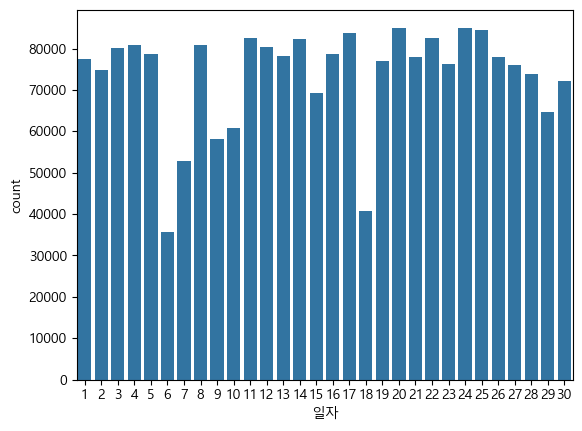

In [50]:
plt.Figure(figsize=(15,4))
sns.countplot(data=bikes_renamed, x='일자')
plt.show()

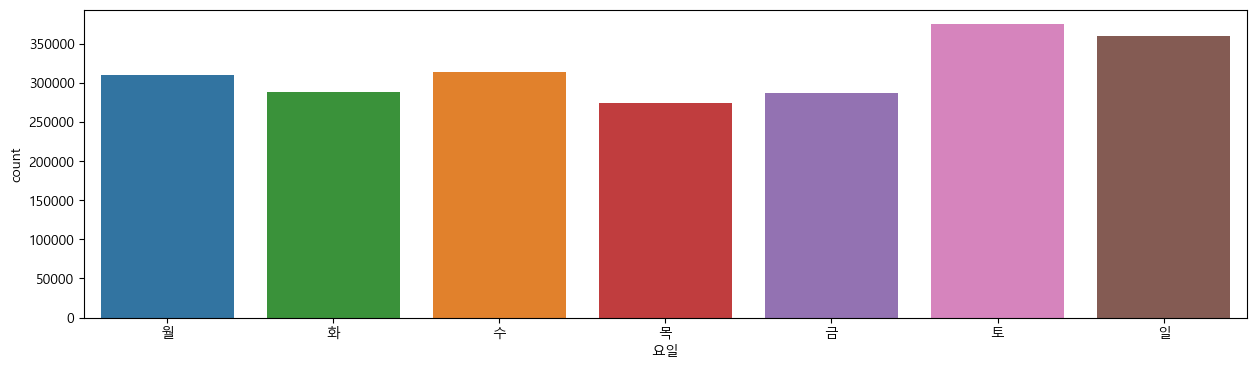

In [51]:
plt.figure(figsize=(15,4))
sns.countplot(data=bikes_renamed, x='요일', hue='요일', order=['월', '화','수','목','금','토','일'])
plt.show()

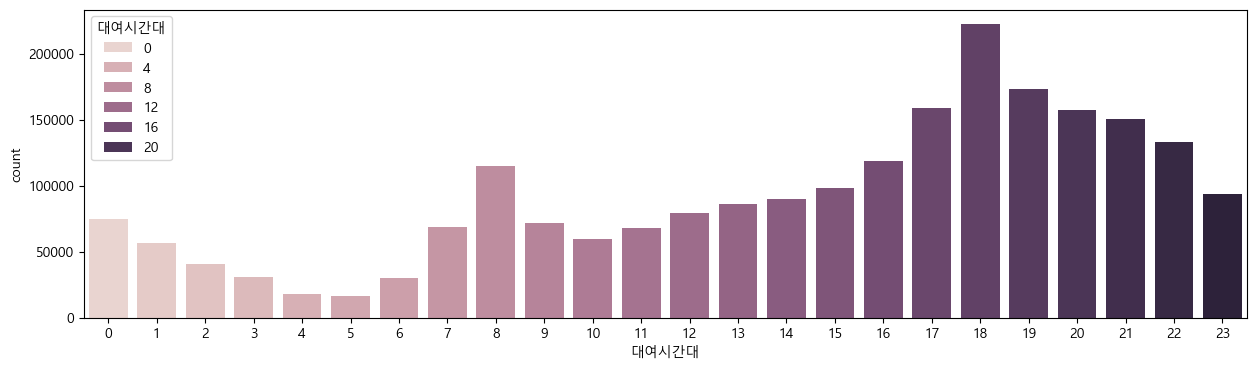

In [52]:
plt.figure(figsize=(15,4))
sns.countplot(data=bikes_renamed, x='대여시간대', hue='대여시간대')
plt.show()

In [ ]:
py